# 通常データに対するSGLD-LLCのキャリブレーション結果

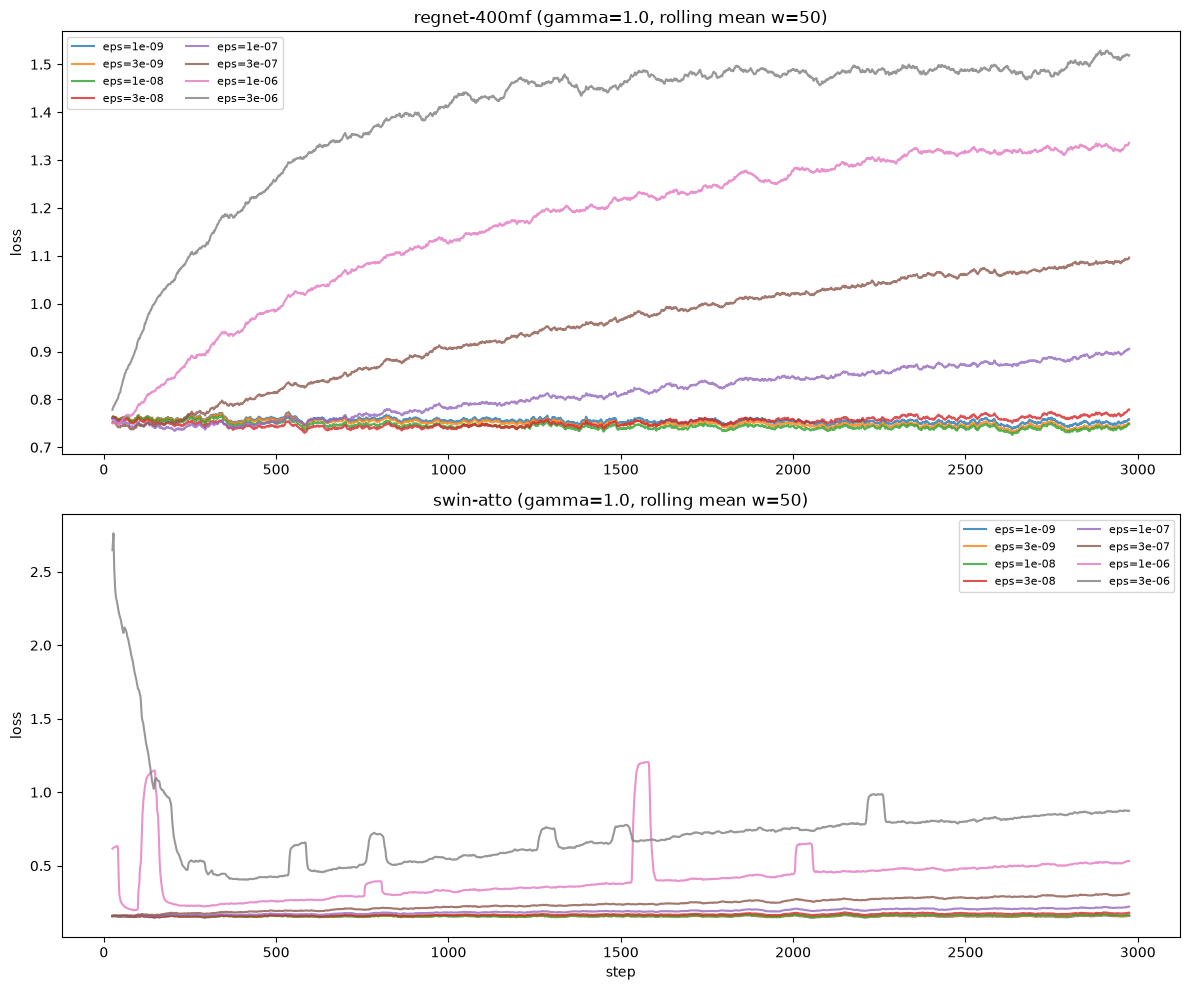

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

def rolling_mean(x, window=50):
    x = np.array(x)
    return np.convolve(x, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

for ax, name, path in zip(axes, ['regnet-400mf', 'swin-atto'], [
    '/home/nakano/server/llc_results_dense/calib_vision_plain_regnet400mf/calib_regnet-400mf_step62059.json',
    '/home/nakano/server/llc_results_dense/calib_vision_plain_swinatto/calib_swin-atto_step62059.json',
]):
    d = json.load(open(path))
    for r in d['records']:
        if r['gamma'] != 1.0:
            continue
        trace = r['loss_trace']
        rm = rolling_mean(trace, window=50)
        ax.plot(np.arange(len(rm)) + 25, rm, label=f"eps={r['epsilon']:.0e}", alpha=0.8)
    ax.set_title(f"{name} (gamma=1.0, rolling mean w=50)")
    ax.set_ylabel("loss")
    ax.legend(fontsize=8, ncol=2)

axes[-1].set_xlabel("step")
plt.tight_layout()
plt.show()
#plt.savefig('/home/nakano/cuda_test/calib_loss_traces.png', dpi=100)
#print("saved")